In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("gurugram_data_realstate.csv")
print(df)
df.info()
print(df.columns)
df.head(10)

            Price              Status  Area Rate per sqft  \
0      10700000.0  Under Construction  1138        9,450    
1      14400000.0  Under Construction  1528        9,450    
2      10700000.0  Under Construction  1138        9,450    
3      40000000.0       Ready to move  4500        8,888    
4      24000000.0  Under Construction  1800       13,333    
...           ...                 ...   ...           ...   
19510  24100000.0       Ready to move  1381       17,500    
19511  36200000.0       Ready to move  2072       17,500    
19512  39100000.0  Under Construction  2445       16,002    
19513  37700000.0  Under Construction  2360       16,001    
19514  36500000.0  Under Construction  2282       16,005    

                                           Property Type    Locality  \
0           2 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
1           3 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
2           2 BHK Apartment in M3M Antalya Hills Ph

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Socity,Company Name,Flat Type
0,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000.0,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3.0,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000.0,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4.0,Outside Socity,Outside,Plot
4,24000000.0,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3.0,Anant Raj Estate Plots,Anant,Floor
5,63800000.0,Ready to move,2282,"28,000",3 BHK Apartment in DLF Park Place,Sector 54,MM India Pvt Ltd,Not approved by RERA,3.0,DLF Park Place,DLF,Apartment
6,4500000.0,Ready to move,920,"4,891",3 BHK Apartment,Sector 3A,seller,Not approved by RERA,3.0,Outside Socity,Outside,Plot
7,4500000.0,Ready to move,1000,"4,500",2 BHK Apartment,Sector 69,seller,Not approved by RERA,2.0,Outside Socity,Outside,Plot
8,9000000.0,Ready to move,1250,"7,200",3 BHK Independent Floor in BPTP Astaire Garden...,Sector 70A,seller,Not approved by RERA,3.0,BPTP Astaire Garden Plots,BPTP,Floor
9,74900000.0,Under Construction,3800,"19,736",4 BHK Apartment in DLF The Arbour,Sector 63,seller,Approved by RERA,4.0,DLF The Arbour,DLF,Apartment


# In this we find the answer of the questions:
1. Which is the costliest flat in the dataset?
2. Which locality has the highest average price?
3. Which locality has the highest rate per square foot?
4. Do ready-to-move properties cost more than under-construction properties?
5. Do RERA-approved properties command a price premium?
6. How does area (sqft) impact property price?
7. Which BHK configuration is the most expensive on average?
8. Which property type (Apartment, Floor, Plot) is the costliest?
9. Do certain builders or companies consistently price higher?
10. Are larger homes always more expensive per square foot?


In [2]:
# cleaning the data:
df.columns = df.columns.str.strip().str.upper().str.replace(" ", "_")
print("This is the columns")
print(df.columns)
df = df.drop_duplicates()
df.info()
df["SOCIETY"] = df["SOCITY"]
print(df)
print(df.columns)
df.info()
df = df.drop("SOCITY", axis=1)
print(df)
df.info()

This is the columns
Index(['PRICE', 'STATUS', 'AREA', 'RATE_PER_SQFT', 'PROPERTY_TYPE', 'LOCALITY',
       'BUILDER_NAME', 'RERA_APPROVAL', 'BHK_COUNT', 'SOCITY', 'COMPANY_NAME',
       'FLAT_TYPE'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 14223 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PRICE          14223 non-null  object 
 1   STATUS         14223 non-null  object 
 2   AREA           14223 non-null  int64  
 3   RATE_PER_SQFT  14223 non-null  object 
 4   PROPERTY_TYPE  14223 non-null  object 
 5   LOCALITY       14223 non-null  object 
 6   BUILDER_NAME   14223 non-null  object 
 7   RERA_APPROVAL  14223 non-null  object 
 8   BHK_COUNT      14223 non-null  float64
 9   SOCITY         14223 non-null  object 
 10  COMPANY_NAME   14223 non-null  object 
 11  FLAT_TYPE      14223 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 1.4

In [3]:
# now we convert the price into the numeric:
# its a numeric columns cleaning:
df["PRICE"] = df["PRICE"].astype(str).str.replace(",","").astype(float)
print(df["PRICE"])
# df.info()
df["AREA"] = df["AREA"].astype(str).str.replace(",","").astype(int)
print(df["AREA"])
df["RATE_PER_SQFT"] = df["RATE_PER_SQFT"].astype(str).str.replace(",", "").astype(int)
print("this is the rate per square foot")
print(df["RATE_PER_SQFT"])
# df.info()
df["BHK_COUNT"] = df["BHK_COUNT"].astype(str).str.replace(" ", "").astype(float).astype(int)
print(df["BHK_COUNT"])

0        10700000.0
1        14400000.0
2        10700000.0
3        40000000.0
4        24000000.0
            ...    
19510    24100000.0
19511    36200000.0
19512    39100000.0
19513    37700000.0
19514    36500000.0
Name: PRICE, Length: 14223, dtype: float64
0        1138
1        1528
2        1138
3        4500
4        1800
         ... 
19510    1381
19511    2072
19512    2445
19513    2360
19514    2282
Name: AREA, Length: 14223, dtype: int64
this is the rate per square foot
0         9450
1         9450
2         9450
3         8888
4        13333
         ...  
19510    17500
19511    17500
19512    16002
19513    16001
19514    16005
Name: RATE_PER_SQFT, Length: 14223, dtype: int64
0        2
1        3
2        2
3        4
4        3
        ..
19510    2
19511    3
19512    3
19513    3
19514    3
Name: BHK_COUNT, Length: 14223, dtype: int64


In [4]:
# It is the categorical columns cleaning:
df["STATUS"] = df["STATUS"].str.strip().str.lower()
df["RERA_APPROVAL"] = df["RERA_APPROVAL"].str.strip().str.lower().map({"approved by rera":True, "not approved by rera":False})
df["FLAT_TYPE"] = df["FLAT_TYPE"].str.strip().str.lower()
print(df["RERA_APPROVAL"])

0         True
1         True
2         True
3        False
4         True
         ...  
19510    False
19511    False
19512     True
19513     True
19514     True
Name: RERA_APPROVAL, Length: 14223, dtype: bool


# now we answering the questions:
1. Which is the costliest flat in the dataset?

In [7]:
costliest_flat = df.loc[df["PRICE"].idxmax()]
print(costliest_flat)
# lets write this ouptut as the sentence:
print(f'The costliest flat is a {costliest_flat["BHK_COUNT"]} BHK flat located in {costliest_flat["LOCALITY"]} priced at {costliest_flat["PRICE"]/10000000} crores in {costliest_flat["SOCIETY"]} society.')

PRICE                                1226300000.0
STATUS                              ready to move
AREA                                        16500
RATE_PER_SQFT                               74323
PROPERTY_TYPE    6 BHK Apartment in DLF Camellias
LOCALITY                                Sector 42
BUILDER_NAME                    Provident Capital
RERA_APPROVAL                               False
BHK_COUNT                                       6
COMPANY_NAME                                  DLF
FLAT_TYPE                               apartment
SOCIETY                             DLF Camellias
Name: 2839, dtype: object
The costliest flat is a 6 BHK flat located in Sector 42 priced at 122.63 crores in  DLF Camellias society.


2. Which locality has the highest average price?

In [13]:
df.groupby("LOCALITY")["PRICE"].mean().idxmax()
highest_avg_price_locality = df.groupby("LOCALITY")["PRICE"].mean().idxmax()
print(f"The locality with the highest average price is {highest_avg_price_locality}.")
print(df.groupby("LOCALITY")["PRICE"].mean().sort_values(ascending=False).head(20))

The locality with the highest average price is Baliawas.
LOCALITY
Baliawas                  5.833333e+08
Sector 42                 5.023612e+08
Beverly Park              1.953667e+08
Aralias Drive             1.636583e+08
Golf Course Road          1.475139e+08
Sector 73                 1.281941e+08
37D Dwarka Exp Gurgaon    1.197000e+08
Ambience Island           1.100000e+08
Sector 24                 1.086423e+08
Sector 113                9.808106e+07
Sector 75                 9.000000e+07
Suncity                   9.000000e+07
Esencia                   9.000000e+07
Sector 54                 8.903798e+07
Alameda                   8.875000e+07
Sector 53                 8.848271e+07
Sohna Road Sector 47      8.690000e+07
Gwal Pahari               8.651667e+07
DLF CITY PHASE I          7.816250e+07
Ardee City                7.450000e+07
Name: PRICE, dtype: float64


3. which locality has the highest rate per square foot ?

In [16]:
highest_rate_locality = df.groupby("LOCALITY")["RATE_PER_SQFT"].mean().idxmax()
print(f"The Locality with the highest rate per square foot is: {highest_rate_locality}.")

The Locality with the highest rate per square foot is: Sector 42.


4. Do ready-to-move properties cost more than under-construction properties ?

In [18]:
ready_to_move_avg_price = df[df["STATUS"] == "Ready to move"]["PRICE"].mean()
under_construction_avg_price = df[df["STATUS"] == "Under Construction"]["PRICE"].mean()
if ready_to_move_avg_price > under_construction_avg_price: 
    print("Ready-to-move properties cost more than under-construction properties.")
else: 
    print("Under-construction properties cost more on average then ready-to-move properties.")
    

Under-construction properties cost more on average then ready-to-move properties.


5. Rera-approved properties commnad a price premium?
   

In [20]:
rera_approved_avg_price = df[df["RERA_APPROVAL"] == True]["PRICE"].mean()
rera_not_approved_avg_price = df[df["RERA_APPROVAL"] == False]["PRICE"].mean()
if rera_approved_avg_price > rera_not_approved_avg_price:
    print("RERA_APPROVED properties command a price permium")
else:
    print("RERA_APPROVED properties do not command a price permium")

RERA_APPROVED properties do not command a price permium


6. How does area impact the price:?

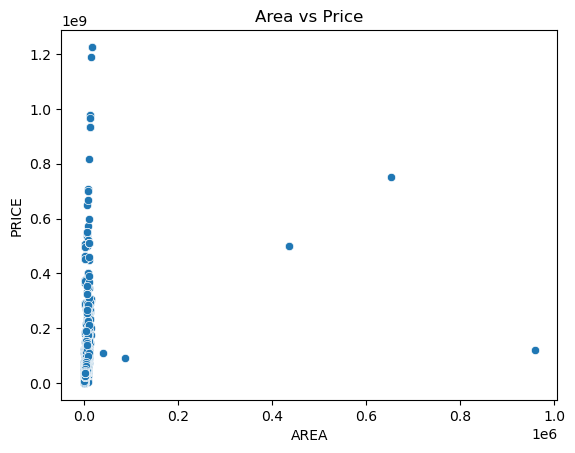

In [21]:
sns.scatterplot(data=df, x ="AREA", y="PRICE")
plt.title("Area vs Price")
plt.show()

7. Which BHK configuraation is the most expensive based on per square foot rate ?


In [25]:
most_expensive_bhk = df.groupby("BHK_COUNT")["RATE_PER_SQFT"].mean().idxmax()
print(f"The most expensive BHK configuration on average is : {most_expensive_bhk} BHK.")



The most expensive BHK configuration on average is : 114 BHK.


8. WHich property is the costliest?


In [27]:
most_expensive_property_type = df.groupby("FLAT_TYPE")["RATE_PER_SQFT"].mean().idxmax()
print(f"The most expensive property type is {most_expensive_property_type}.")


The most expensive property type is villa.


9. Do certain builders price higher ?

In [28]:
print(df.groupby("COMPANY_NAME")["RATE_PER_SQFT"].mean().sort_values(ascending=False).head(5))


COMPANY_NAME
Camelliaass    44724.333333
Cameliaas      40000.000000
Tulip          28571.121495
Prom           27358.600000
Magnoliaass    26666.000000
Name: RATE_PER_SQFT, dtype: float64
